![JohnSnowLabs](https://nlp.johnsnowlabs.com/assets/images/logo.png)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/JohnSnowLabs/visual-nlp-workshop/blob/master/jupyter/deid-and-obfuscation/SparkOCRVLMDeIdentification.ipynb)

In [1]:
license = ""
secret = ""
nlp_secret = ""
aws_access_key = ""
aws_secret_key = ""

version = secret.split("-")[0]
spark_ocr_jar_path = "../../../target/scala-2.12"

In [2]:
from sparkocr import start
import os
from pyspark import SparkConf

if license:
    os.environ['JSL_OCR_LICENSE'] = license
    os.environ['SPARK_NLP_LICENSE'] = license

if aws_access_key:
    os.environ['AWS_ACCESS_KEY'] = aws_access_key
    os.environ['AWS_SECRET_ACCESS_KEY'] = aws_secret_key


spark = start(secret=secret,
              nlp_secret=nlp_secret,
              jar_path=spark_ocr_jar_path,
              use_gpu=True,
              nlp_internal="6.4.1")
spark

Spark version: 3.4.0
Spark NLP version: 6.4.2
Spark NLP for Healthcare version: 6.4.1
Spark OCR version: 6.4.2

:: loading settings :: url = jar:file:/usr/local/lib/python3.11/dist-packages/pyspark/jars/ivy-2.5.1.jar!/org/apache/ivy/core/settings/ivysettings.xml


Ivy Default Cache set to: /root/.ivy2/cache
The jars for the packages stored in: /root/.ivy2/jars
com.johnsnowlabs.nlp#spark-nlp-gpu_2.12 added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-45d98481-6845-4446-bcf8-cc216acb3a46;1.0
	confs: [default]
	found com.johnsnowlabs.nlp#spark-nlp-gpu_2.12;6.4.2 in central
	found com.typesafe#config;1.4.2 in central
	found org.rocksdb#rocksdbjni;6.29.5 in central
	found com.amazonaws#aws-java-sdk-s3;1.12.500 in central
	found com.amazonaws#aws-java-sdk-kms;1.12.500 in central
	found com.amazonaws#aws-java-sdk-core;1.12.500 in central
	found commons-logging#commons-logging;1.1.3 in central
	found commons-codec#commons-codec;1.15 in central
	found org.apache.httpcomponents#httpclient;4.5.13 in central
	found org.apache.httpcomponents#httpcore;4.4.13 in central
	found software.amazon.ion#ion-java;1.0.2 in central
	found joda-time#joda-time;2.8.1 in central
	found com.amazonaws#jmespath-java;1.12.500 in central
	fou

# Import Visual NLP, Healthcare NLP and Spark-NLP

In [3]:
from sparkocr.transformers import *
from sparkocr.enums import *
from sparkocr.utils import *
from pyspark.ml import PipelineModel, Pipeline

from sparknlp.annotator import *
from sparknlp.base import *
import sparknlp_jsl
from sparknlp_jsl.annotator import *

from pyspark.sql.types import *
import pyspark.sql.functions as F
from pyspark.ml import PipelineModel, Pipeline
from pyspark.ml.feature import SQLTransformer
import pkg_resources

import numpy as np
from PIL import Image
import io

/tmp/ipykernel_27252/1081714449.py:15: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


In [4]:
def write_pdf_to_disk(df, SAVE_OUTPUT_PDF):
  """
  df -> Result Dataframe from deid task.
  SAVE_OUTPUT_PDF -> Path to save output pdf.
  """

  import os

  os.makedirs(SAVE_OUTPUT_PDF, exist_ok=True)

  for row in df.select("path", "pdf").toLocalIterator():
    filename = row.asDict()["path"]
    basename = os.path.basename(filename).replace(".pdf", "")

    result_name = basename + "_result.pdf"

    savename = os.path.join(SAVE_OUTPUT_PDF, result_name)
    print(f"Saving File -> {savename}")

    pdfFile = open(savename, "wb")
    pdfFile.write(row.asDict()["pdf"])
    pdfFile.close()

## Load MedicalVisionLLM 1 Billion model for OCR

In [5]:
from sparkocr.transformers.medical_vision_llm import MedicalVisionLLM

model = MedicalVisionLLM.pretrained("jsl-ocr-gguf-vlm1", "en", "clinical/ocr") \
  .setInputCols(["caption_document", "image_assembler"]) \
  .setOutputCol("completions") \
  .setNGpuLayers(99) \
  .setNCtx(32768) \
  .setNParallel(1) \
  .setNBatch(2048) \
  .setNUbatch(1024) \
  .setNPredict(2048) \
  .setTemperature(0.01) \
  .setTopK(1) \
  .setTopP(1.0) \
  .setRepeatPenalty(1.03) \
  .setRepeatLastN(256) \
  .setStopStrings(["<\uff5chy_Assistant\uff5c>", "<\uff5chy_place\u2581holder\u2581no\u25812\uff5c>"]) \
  .setMinKeep(0) \
  .setNProbs(0) \
  .setOutputCol("completions") \
  .setBatchSize(1) \
  .setDisableLog(False)

jsl-ocr-gguf-vlm1 download started this may take some time.
Approximate size to download 1.5 GB
jsl-ocr-gguf-vlm1 download started this may take some time.
Approximate size to download 1.5 GB


26/07/07 10:48:13 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
26/07/07 10:48:13 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.


Download done! Loading the resource.


Extracted 'libjllama.so' to '/tmp/libjllama.so'


ggml_cuda_init: found 1 CUDA devices (Total VRAM: 45488 MiB):
  Device 0: NVIDIA A40, compute capability 8.6, VMM: yes, VRAM: 45488 MiB


## Define a Healthcare DeIdentification Pipeline

In [6]:
def deid_pipeline(input_text="text", ner_output = "merged_ner_chunk"):
    
    document_assembler = DocumentAssembler() \
        .setInputCol(input_text) \
        .setOutputCol("document") \
        .setCleanupMode("disabled")

    sentence_detector = SentenceDetector() \
        .setInputCols(["document"]) \
        .setOutputCol("sentence") \
        .setCustomBounds(["\n"]) \
        .setUseCustomBoundsOnly(False)
    
    tokenizer = Tokenizer()\
        .setInputCols(["sentence"])\
        .setOutputCol("token")
    
    zeroshot_ner_deid_generic_nonMedical_medium_labels = ["NAME", "DATE", "ID", "CONTACT", "PROFESSION"]
    zeroshot_ner_deid_generic_nonMedical_medium = PretrainedZeroShotNER().pretrained("zeroshot_ner_deid_generic_nonMedical_medium", "en", "clinical/models")\
        .setInputCols("sentence", "token")\
        .setOutputCol("ner_zeroshot_ner_deid_generic_nonMedical_medium")\
        .setPredictionThreshold(0.5)\
        .setLabels(zeroshot_ner_deid_generic_nonMedical_medium_labels)
    
    zeroshot_ner_deid_generic_nonMedical_medium_converter = NerConverterInternal()\
        .setInputCols("sentence", "token", "ner_zeroshot_ner_deid_generic_nonMedical_medium")\
        .setOutputCol("ner_conv_zeroshot_ner_deid_generic_nonMedical_medium") \
        .setThreshold(0.90)
    
    zeroshot_ner_deid_subentity_nonMedical_large_labels = ["ACCOUNTNUM", "DATE", "DOCTOR", "EMAIL", "GENDER", 
                                                           "IDNUM", "MEDICALRECORD", "NAME", "ORGANIZATION", 
                                                           "PATIENT", "PHONE", "PROFESSION", "SSN"]
    
    zeroshot_ner_deid_subentity_nonMedical_large = PretrainedZeroShotNER().pretrained("zeroshot_ner_deid_subentity_nonMedical_large", "en", "clinical/models")\
        .setInputCols("sentence", "token")\
        .setOutputCol("ner_zeroshot_ner_deid_subentity_nonMedical_large")\
        .setPredictionThreshold(0.5)\
        .setLabels(zeroshot_ner_deid_subentity_nonMedical_large_labels)
    
    zeroshot_ner_deid_subentity_nonMedical_large_converter = NerConverterInternal()\
        .setInputCols("sentence", "token", "ner_zeroshot_ner_deid_subentity_nonMedical_large")\
        .setOutputCol("ner_conv_zeroshot_ner_deid_subentity_nonMedical_large") \
        .setThreshold(0.90)

    medium_labels = ['CITY', 'STREET', 'COUNTRY', 'ORGANIZATION']
    pretrained_zero_shot_ner_medium = PretrainedZeroShotNER().pretrained("zeroshot_ner_deid_subentity_merged_medium", "en", "clinical/models")\
        .setInputCols("sentence", "token")\
        .setOutputCol("ner_zeroshot_ner_deid_subentity_docwise_medium")\
        .setPredictionThreshold(0.5)\
        .setLabels(medium_labels)

    ner_converter_medium = NerConverterInternal() \
        .setInputCols("sentence", "token", "ner_zeroshot_ner_deid_subentity_docwise_medium") \
        .setOutputCol("ner_zeroshot_ner_deid_subentity_docwise_medium_chunk") \
        .setThreshold(0.90)
    
    chunk_merger = ChunkMergeApproach()\
        .setInputCols('ner_zeroshot_ner_deid_subentity_docwise_medium_chunk', 'ner_conv_zeroshot_ner_deid_generic_nonMedical_medium', 'ner_conv_zeroshot_ner_deid_subentity_nonMedical_large')\
        .setOutputCol(ner_output)\
        .setMergeOverlapping(True)
    
    pipeline = Pipeline(stages=[
        document_assembler,
        sentence_detector,
        tokenizer,
        zeroshot_ner_deid_generic_nonMedical_medium,
        zeroshot_ner_deid_generic_nonMedical_medium_converter,
        zeroshot_ner_deid_subentity_nonMedical_large,
        zeroshot_ner_deid_subentity_nonMedical_large_converter,
        pretrained_zero_shot_ner_medium,
        ner_converter_medium,
        chunk_merger
    ])

    return pipeline

# Combined Visual NLP and Healthcare NLP Pipeline

This pipeline combines **Visual NLP** for OCR text and bounding-box extraction with **Healthcare NLP** for PHI detection and de-identification.

* `ImageToPdf` is removed in this version so that intermediate image outputs can be inspected.
* The OCR model used here is `MedicalVisionLLM`, which extracts:

  * page text
  * text bounding boxes

### `deid_pipeline(input_text="text", ner_output="merged_ner_chunk")` is used for text-based PHI extraction.

### Parameters

* `input_text="text"`
  Uses the text extracted from OCR as input to the Healthcare NLP de-identification pipeline.

* `ner_output="merged_ner_chunk"`
  Stores the extracted PHI entities detected from the OCR text.


## Working with images

For working with image files instead of PDFs, replace `pdf_to_image` with `binary_to_image`.

```python
bin_to_image = BinaryToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setImageDimsCol("frame_dims")
```

In [7]:
pdf_to_image = PdfToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setKeepInput(False) \
    .setCompressImage(True) \
    .setImageDimsCol("frame_dims")

caption_assembler = DocumentAssembler() \
    .setInputCol("caption") \
    .setOutputCol("caption_document")

schema_converter_assembler = ImageSchemaConverter() \
    .setInputCol("image") \
    .setOutputCol("image_assembler") \
    .setOutputSchema(ImageSchemaConversion.ASSEMBLER) \
    .setKeepInput(False)

coordinate_extract = DocumentCoordinatesToText() \
    .setInputCol("completions") \
    .setImageDimsCol("frame_dims") \
    .setOutputCol("text") \
    .setPageMatrixCol("positions") \
    .setRegionCol("regions")

schema_converter_internal = ImageSchemaConverter() \
    .setInputCol("image_assembler") \
    .setOutputCol("image") \
    .setOutputSchema(ImageSchemaConversion.INTERNAL) \
    .setKeepInput(False)

position_finder = PositionFinder() \
    .setInputCols("merged_ner_chunk") \
    .setOutputCol("coordinates") \
    .setPageMatrixCol("positions") \
    .setSmoothCoordinates(True)

draw_regions = ImageDrawRegions() \
    .setInputCol("image") \
    .setInputRegionsCol("coordinates") \
    .setRectColor(Color.black) \
    .setFilledRect(True) \
    .setOutputCol("image_with_regions")

img_to_pdf = ImageToPdf() \
    .setPageNumCol("pagenum") \
    .setOriginCol("path") \
    .setOutputCol("pdf") \
    .setInputCol("image_with_regions") \
    .setAggregatePages(True)

pipeline = Pipeline(stages=[
    pdf_to_image,
    caption_assembler,
    schema_converter_assembler,
    model,
    coordinate_extract,
    schema_converter_internal,
    deid_pipeline(input_text="text", ner_output="merged_ner_chunk"),
    position_finder,
    draw_regions,
    # disable image to pdf to see intermediate results
    #img_to_pdf
])

zeroshot_ner_deid_generic_nonMedical_medium download started this may take some time.
Approximate size to download 753.2 MB
[ | ]

26/07/07 10:48:45 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
26/07/07 10:48:45 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.


zeroshot_ner_deid_generic_nonMedical_medium download started this may take some time.
Approximate size to download 753.2 MB
Download done! Loading the resource.
[ / ]

[ — ]

[OK!]
zeroshot_ner_deid_subentity_nonMedical_large download started this may take some time.
Approximate size to download 1.7 GB
[ | ]

...

[OK!]
zeroshot_ner_deid_subentity_merged_medium download started this may take some time.
Approximate size to download 674 MB
[ | ]

26/07/07 10:49:17 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
26/07/07 10:49:18 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
26/07/07 10:49:18 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.


zeroshot_ner_deid_subentity_merged_medium download started this may take some time.
Approximate size to download 674 MB
Download done! Loading the resource.


[ / ]

[OK!]


In [8]:
# Define the prompt for OCR 
ocr_prompt = "Detect and recognize text in the image, and output the text coordinates in a formatted manner."

## PDF DeIdentification Example - 1

In [9]:
path = "./source_pdfs/Easy/PDF_Deid_Deidentification_0.pdf"

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(ocr_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [10]:
result = pipeline.fit(df).transform(df).cache()
result.columns

26/07/07 10:49:32 WARN package: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'pagenum',
 'documentnum',
 'frame_dims',
 'caption_document',
 'completions',
 'text',
 'regions',
 'positions',
 'image',
 'document',
 'sentence',
 'token',
 'ner_zeroshot_ner_deid_generic_nonMedical_medium',
 'ner_conv_zeroshot_ner_deid_generic_nonMedical_medium',
 'ner_zeroshot_ner_deid_subentity_nonMedical_large',
 'ner_conv_zeroshot_ner_deid_subentity_nonMedical_large',
 'ner_zeroshot_ner_deid_subentity_docwise_medium',
 'ner_zeroshot_ner_deid_subentity_docwise_medium_chunk',
 'merged_ner_chunk',
 'coordinates',
 'image_with_regions',
 'exception']

In [11]:
# display_images_horizontal(result.orderBy("pagenum"), "image,image_with_regions")

In [12]:
# Save PDF result to disk
result_pdf = img_to_pdf.transform(result)
result_pdf.columns

['path', 'images', 'pages', 'pdf', 'exception']

In [13]:
# write_pdf_to_disk(df=result_pdf, SAVE_OUTPUT_PDF="./results") 

## PDF DeIdentification Example - 2

In [14]:
path = "./source_pdfs/Medium/PDF_Deid_Deidentification_Medium_0.pdf"

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(ocr_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [15]:
result = pipeline.fit(df).transform(df).cache()
result.columns

['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'pagenum',
 'documentnum',
 'frame_dims',
 'caption_document',
 'completions',
 'text',
 'regions',
 'positions',
 'image',
 'document',
 'sentence',
 'token',
 'ner_zeroshot_ner_deid_generic_nonMedical_medium',
 'ner_conv_zeroshot_ner_deid_generic_nonMedical_medium',
 'ner_zeroshot_ner_deid_subentity_nonMedical_large',
 'ner_conv_zeroshot_ner_deid_subentity_nonMedical_large',
 'ner_zeroshot_ner_deid_subentity_docwise_medium',
 'ner_zeroshot_ner_deid_subentity_docwise_medium_chunk',
 'merged_ner_chunk',
 'coordinates',
 'image_with_regions',
 'exception']

26/07/07 10:49:47 WARN DAGScheduler: Broadcasting large task binary with size 1911.8 KiB
Using CUDA============================>                             (4 + 4) / 8]
2026-07-07 10:50:40.498972141 [W:onnxruntime:, transformer_memcpy.cc:111 ApplyImpl] 45 Memcpy nodes are added to the graph main_graph for CUDAExecutionProvider. It might have negative impact on performance (including unable to run CUDA graph). Set session_options.log_severity_level=1 to see the detail logs before this message.
2026-07-07 10:50:40.512630721 [W:onnxruntime:, session_state.cc:1327 VerifyEachNodeIsAssignedToAnEp] Some nodes were not assigned to the preferred execution providers which may or may not have an negative impact on performance. e.g. ORT explicitly assigns shape related ops to CPU to improve perf.
2026-07-07 10:50:40.512649283 [W:onnxruntime:, session_state.cc:1329 VerifyEachNodeIsAssignedToAnEp] Rerunning with verbose output on a non-minimal build will show node assignments.
Using CUDA
2026-07-07

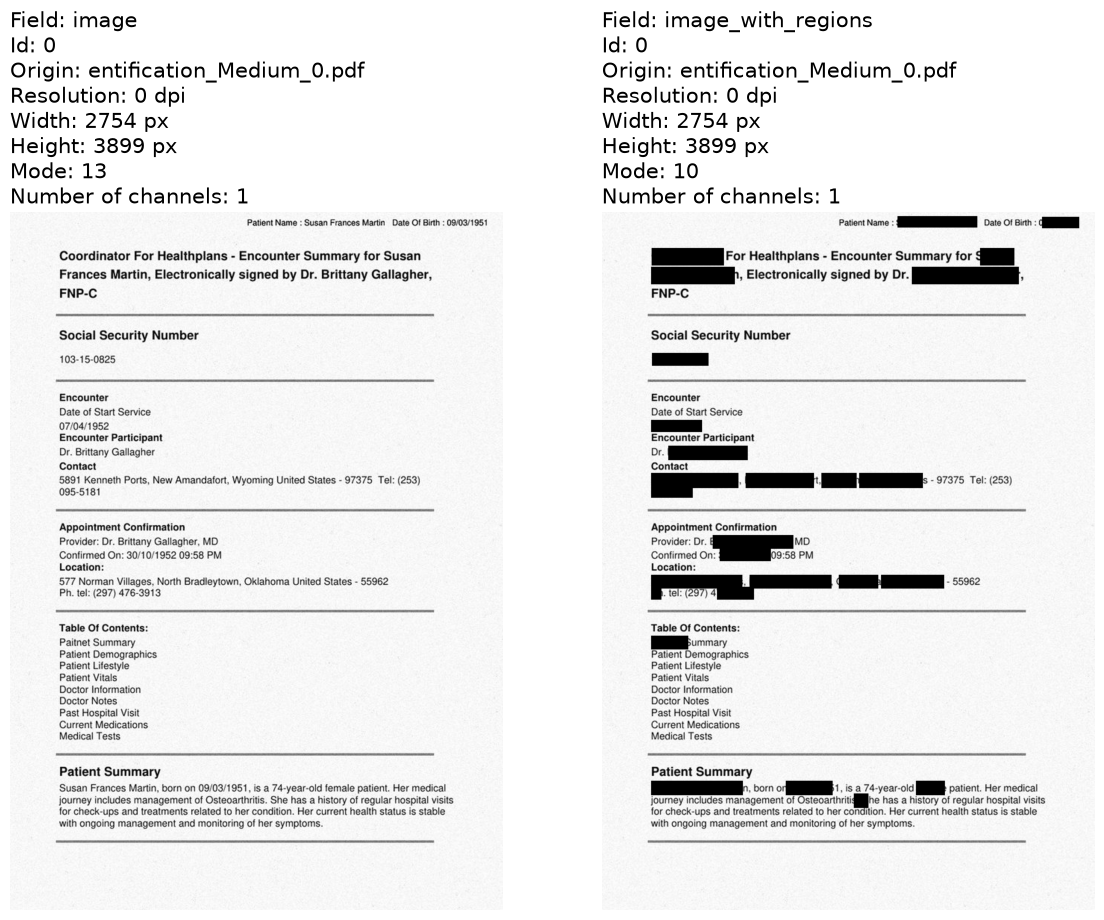

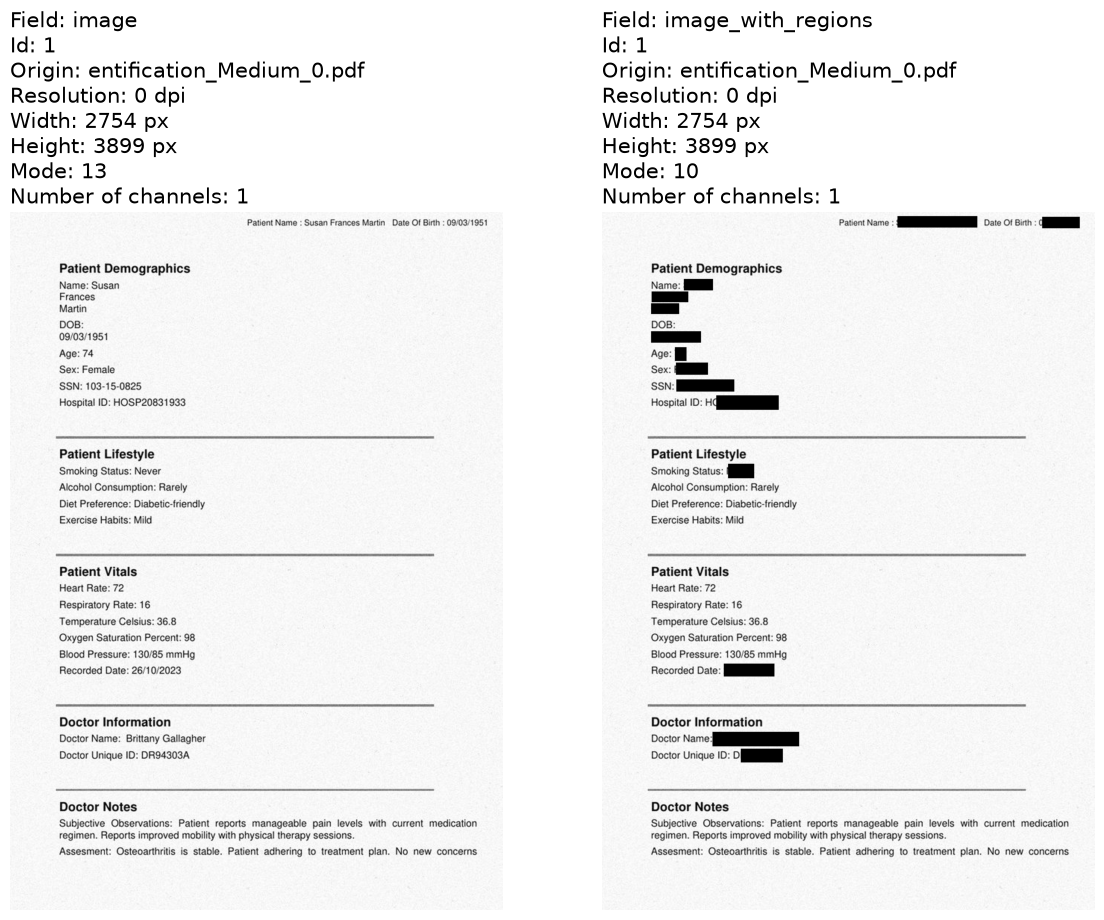

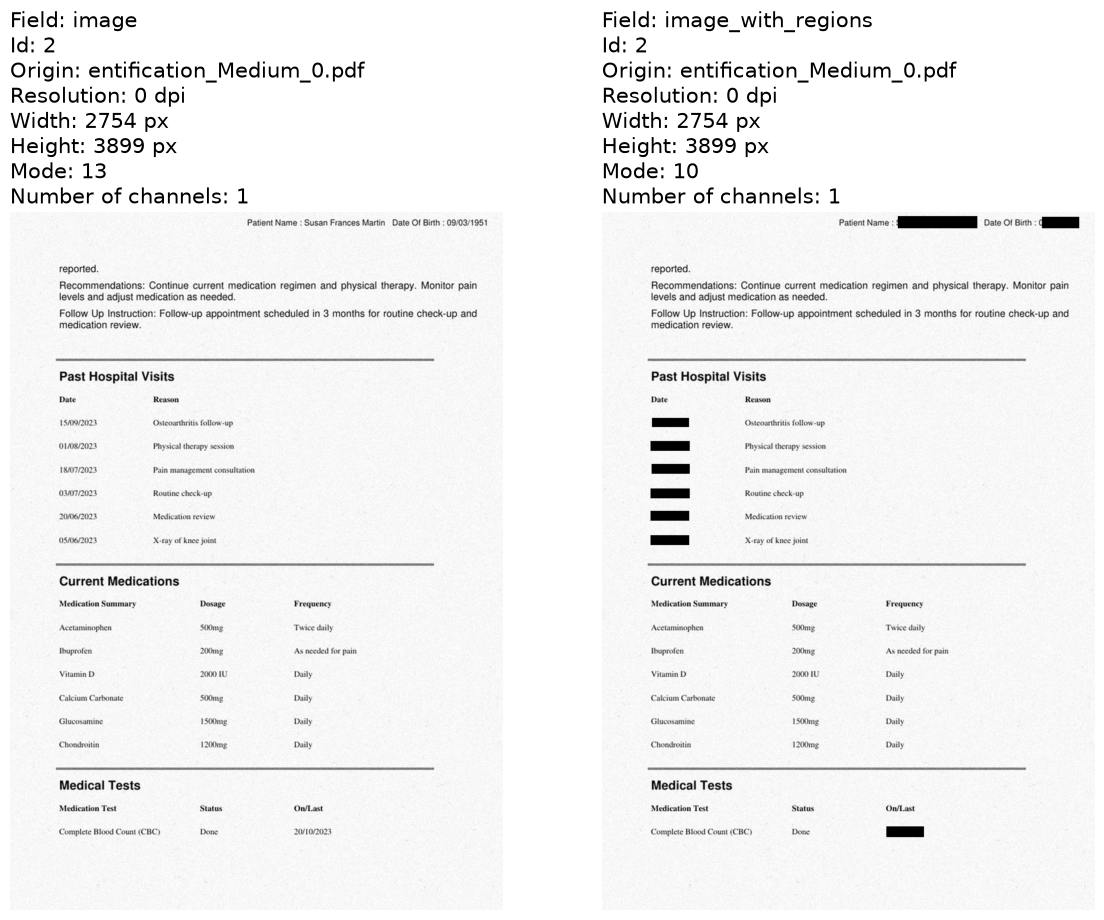

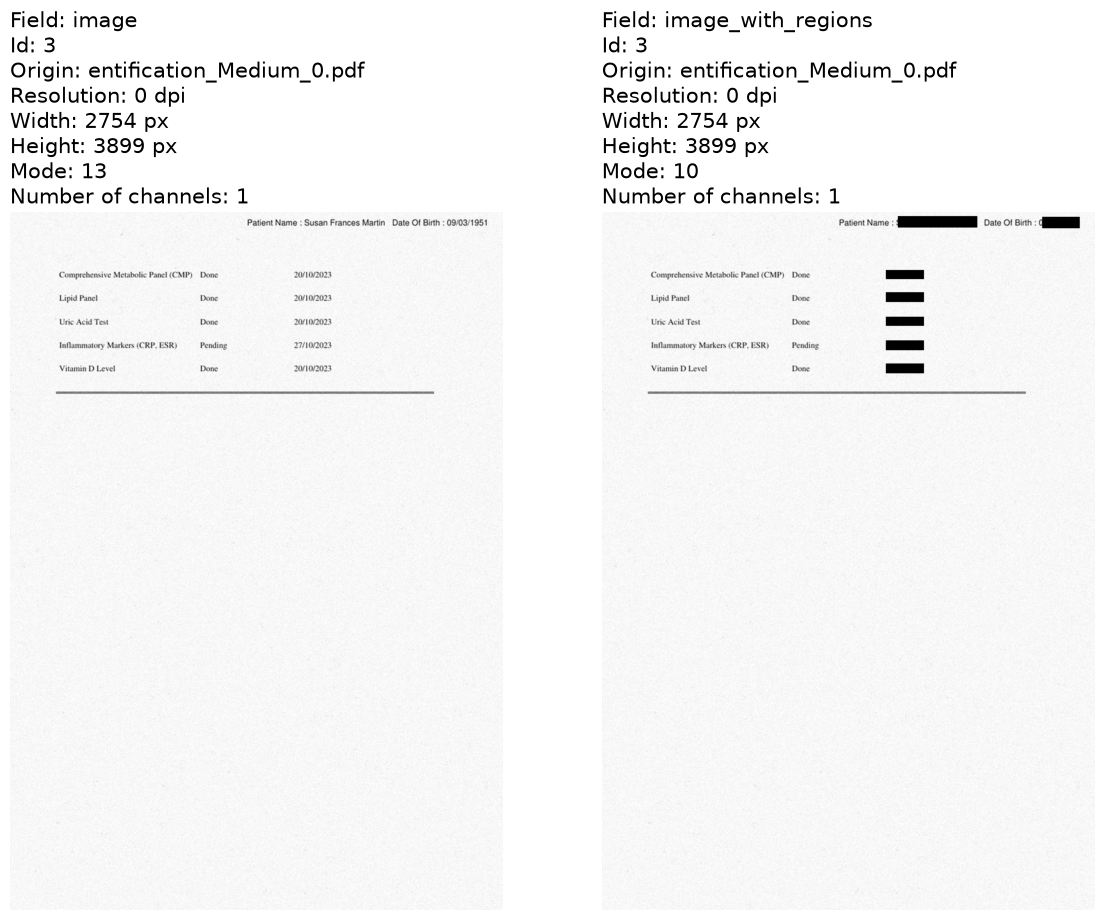

In [16]:
display_images_horizontal(result.orderBy("pagenum"), "image,image_with_regions")

# LLM for Entity Extraction using MedicalLLMEntityExtractor

In [17]:
entity_extractor = MedicalLLMEntityExtractor.pretrained("jsl_meds_4b_q16_v5", "en", "clinical/models") \
    .setInputCols(["sentence"]) \
    .setOutputCol("entities") \
    .setNGpuLayers(99) \
    .setNCtx(4096) \
    .setNPredict(500) \
    .setTemperature(0.0) \
    .setBatchSize(4) \
    .setTopK(1) \
    .setTopP(1.0)

jsl_meds_4b_q16_v5 download started this may take some time.
Approximate size to download 5.7 GB
[ | ]

26/07/07 10:51:50 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
26/07/07 10:51:51 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
26/07/07 10:51:51 WARN S3AbortableInputStream: Not all bytes were read from the S3ObjectInputStream, aborting HTTP connection. This is likely an error and may result in sub-optimal behavior. Request only the bytes you need via a ranged GET or drain the input stream after use.
jsl_meds_4b_q16_v5 download started this may take some time.
Approximate size to download 5.7 GB
Download done! Loading the resource.
Failed to cast to class of file:/ro

[OK!]


# Define Healthcare LLM DeIdentification Pipeline

In [18]:
def llm_deidentification(entity_types, phi_few_shot, input_text="text", ner_output="ner"):

    document_assembler = DocumentAssembler() \
        .setInputCol("text") \
        .setOutputCol("document") \
        .setCleanupMode("disabled")
    
    sentence_detector = SentenceDetector() \
        .setInputCols(["document"]) \
        .setOutputCol("sentence") \
        .setCustomBounds(["\n"]) \
        .setUseCustomBoundsOnly(False)

    entity_extractor.setEntityTypes(entity_types)
    entity_extractor.setFewShotExamples(phi_few_shot)
    entity_extractor.setOutputCol(ner_output)
    
    pipeline = Pipeline(stages=[
        document_assembler,
        sentence_detector,
        entity_extractor
    ])

    return pipeline

# Combined Visual NLP and Healthcare NLP Pipeline (LLM)

This pipeline combines **Visual NLP** for OCR text and bounding-box extraction with **Healthcare NLP** for LLM-based PHI detection and de-identification.

### Notes

* `ImageToPdf` is removed in this version so that intermediate image outputs can be inspected.
* The OCR model used here is `MedicalVisionLLM`, which extracts:

  * page text
  * text bounding boxes
## `llm_deidentification(entity_types, phi_few_shot, input_text="text", ner_output="merged_ner_chunk")` is used for text-based PHI extraction.
* `entity_extractor` uses an LLM-based medical entity extractor to identify PHI entities from OCR text.

### Few-shot PHI examples

```python
phi_few_shot = [
    (
        "Kimberly Lawrence, born on 24/05/1977, is a 46-year-old Female",
        '{"extractions": [{"entity": "PATIENT", "text": "Kimberly Lawrence"}, '
        '{"entity": "DATE", "text": "24/05/1977"}, '
        '{"entity": "AGE", "text": "46"}, '
        '{"entity": "Gender", "text": "Female"}]}'
    ),
    (
        "Sierra Valley Medical Institute INC (402) 738-5912 22/04/2025",
        '{"extractions": [{"entity": "HOSPITAL", "text": "Sierra Valley Medical Institute INC"}, '
        '{"entity": "PHONE", "text": "(402) 738-5912"}, '
        '{"entity": "DATE", "text": "22/04/2025"}]}'
    ),
]
```

These examples guide the LLM entity extractor on how PHI entities should be identified and returned.

### Entity types

```python
entity_types = [
    "PATIENT::The full name of the patient as written in the text. Cannot be Patient.",
    "DOCTOR::The name of the physician, provider, or clinical staff member.",
    "HOSPITAL::The name of a hospital, clinic, medical center, or healthcare facility.",
    "DATE::Any date including admission dates, discharge dates, dates of birth, or appointment dates. Should strictly be date format.",
    "AGE::The patient's age or age range, especially if 90 years or older.",
    "PHONE::A telephone number, fax number, or pager number.",
    "ID::A patient identifier such as MRN, SSN, insurance ID, account number, or episode number.",
]
```

These entity definitions specify the PHI categories that the LLM should extract from the OCR text.

### Parameters

* `entity_types`
  Defines the PHI entity labels and descriptions used by the LLM-based entity extractor.

* `phi_few_shot`
  Provides few-shot examples to help the LLM understand the expected extraction format.

* `input_text="text"`
  Uses the text extracted from OCR as input to the Healthcare NLP de-identification pipeline.

* `ner_output="merged_ner_chunk"`
  Stores the extracted PHI entities detected from the OCR text.

## Working with images

For working with image files instead of PDFs, replace `pdf_to_image` with `binary_to_image`.

```python
bin_to_image = BinaryToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setImageDimsCol("frame_dims")
```

In [19]:
pdf_to_image = PdfToImage() \
    .setInputCol("content") \
    .setOutputCol("image") \
    .setKeepInput(False) \
    .setCompressImage(True) \
    .setImageDimsCol("frame_dims")

caption_assembler = DocumentAssembler() \
    .setInputCol("caption") \
    .setOutputCol("caption_document")

schema_converter_assembler = ImageSchemaConverter() \
    .setInputCol("image") \
    .setOutputCol("image_assembler") \
    .setOutputSchema(ImageSchemaConversion.ASSEMBLER) \
    .setKeepInput(False)

coordinate_extract = DocumentCoordinatesToText() \
    .setInputCol("completions") \
    .setImageDimsCol("frame_dims") \
    .setOutputCol("text") \
    .setPageMatrixCol("positions") \
    .setRegionCol("regions")

schema_converter_internal = ImageSchemaConverter() \
    .setInputCol("image_assembler") \
    .setOutputCol("image") \
    .setOutputSchema(ImageSchemaConversion.INTERNAL) \
    .setKeepInput(False)

position_finder = PositionFinder() \
    .setInputCols("merged_ner_chunk") \
    .setOutputCol("coordinates") \
    .setPageMatrixCol("positions") \
    .setSmoothCoordinates(True)

draw_regions = ImageDrawRegions() \
    .setInputCol("image") \
    .setInputRegionsCol("coordinates") \
    .setRectColor(Color.black) \
    .setFilledRect(True) \
    .setOutputCol("image_with_regions")

img_to_pdf = ImageToPdf() \
    .setPageNumCol("pagenum") \
    .setOriginCol("path") \
    .setOutputCol("pdf") \
    .setInputCol("image_with_regions") \
    .setAggregatePages(True)

phi_few_shot = [
    (
        "Kimberly Lawrence, born on 24/05/1977, is a 46-year-old Female",
        '{"extractions": [{"entity": "PATIENT", "text": "Kimberly Lawrence"}, '
        '{"entity": "DATE", "text": "24/05/1977"}, '
        '{"entity": "AGE", "text": "46"}, '
        '{"entity": "Gender", "text": "Female"}]}'
    ),
    (
        "Sierra Valley Medical Institute INC (402) 738-5912 22/04/2025",
        '{"extractions": [{"entity": "HOSPITAL", "text": "Sierra Valley Medical Institute INC"}, '
        '{"entity": "PHONE", "text": "(402) 738-5912"}, '
        '{"entity": "DATE", "text": "22/04/2025"}]}'
    ),
]

entity_types = [
        "PATIENT::The full name of the patient as written in the text. Cannot be Patient.",
        "DOCTOR::The name of the physician, provider, or clinical staff member.",
        "HOSPITAL::The name of a hospital, clinic, medical center, or healthcare facility.",
        "DATE::Any date including admission dates, discharge dates, dates of birth, or appointment dates. Should strictly be date format.",
        "AGE::The patient's age or age range, especially if 90 years or older.",
        "PHONE::A telephone number, fax number, or pager number.",
        "ID::A patient identifier such as MRN, SSN, insurance ID, account number, or episode number.",
    ]

llm_pipeline = Pipeline(stages=[
    pdf_to_image,
    caption_assembler,
    schema_converter_assembler,
    model,
    coordinate_extract,
    schema_converter_internal,
    llm_deidentification(entity_types, phi_few_shot, input_text="text", ner_output="merged_ner_chunk"),
    position_finder,
    draw_regions,
    # disable image to pdf to see intermediate results
    #img_to_pdf
])

In [20]:
path = "./source_pdfs/Easy/PDF_Deid_Deidentification_0.pdf"

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(ocr_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [21]:
result = llm_pipeline.fit(df).transform(df)
result.columns

['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'pagenum',
 'documentnum',
 'frame_dims',
 'caption_document',
 'completions',
 'text',
 'regions',
 'positions',
 'image',
 'document',
 'sentence',
 'merged_ner_chunk',
 'coordinates',
 'image_with_regions',
 'exception']

In [22]:
# display_images_horizontal(result.orderBy("pagenum"), "image,image_with_regions")

In [23]:
# Save PDF result to disk
result_pdf = img_to_pdf.transform(result)
result_pdf.columns

['path', 'images', 'pages', 'pdf', 'exception']

In [24]:
# write_pdf_to_disk(df=result_pdf, SAVE_OUTPUT_PDF="./results")

## Test MedicalLLMEntityExtractor on a Similar PDF

This section reuses the same `phi_few_shot` examples and `entity_types` definitions with `MedicalLLMEntityExtractor`, but applies them to a different PDF file that has the same document structure.

In [25]:
path = "./source_pdfs/Easy/PDF_Deid_Deidentification_10.pdf"

df = spark.read.format("binaryFile").load(path).withColumn("caption", F.lit(ocr_prompt))
df.columns

['path', 'modificationTime', 'length', 'content', 'caption']

In [26]:
result = llm_pipeline.fit(df).transform(df)
result.columns

['path',
 'modificationTime',
 'length',
 'caption',
 'total_pages',
 'pagenum',
 'documentnum',
 'frame_dims',
 'caption_document',
 'completions',
 'text',
 'regions',
 'positions',
 'image',
 'document',
 'sentence',
 'merged_ner_chunk',
 'coordinates',
 'image_with_regions',
 'exception']

26/07/07 10:52:16 WARN PDType1Font: Using fallback font LiberationSans for base font Times-Roman
26/07/07 10:52:16 WARN PDType1Font: Using fallback font LiberationSans for base font Times-Bold
26/07/07 10:52:16 WARN PDType1Font: Using fallback font LiberationSans for base font Times-Italic
26/07/07 10:52:16 WARN PDType1Font: Using fallback font LiberationSans for base font Times-BoldItalic
26/07/07 10:52:16 WARN PDType1Font: Using fallback font LiberationSans for base font Helvetica
26/07/07 10:52:16 WARN PDType1Font: Using fallback font LiberationSans for base font Helvetica-Bold
26/07/07 10:52:16 WARN PDType1Font: Using fallback font LiberationSans for base font Helvetica-Oblique
26/07/07 10:52:16 WARN PDType1Font: Using fallback font LiberationSans for base font Helvetica-BoldOblique
26/07/07 10:52:16 WARN PDType1Font: Using fallback font LiberationSans for base font Courier
26/07/07 10:52:16 WARN PDType1Font: Using fallback font LiberationSans for base font Courier-Bold
26/07/07 10

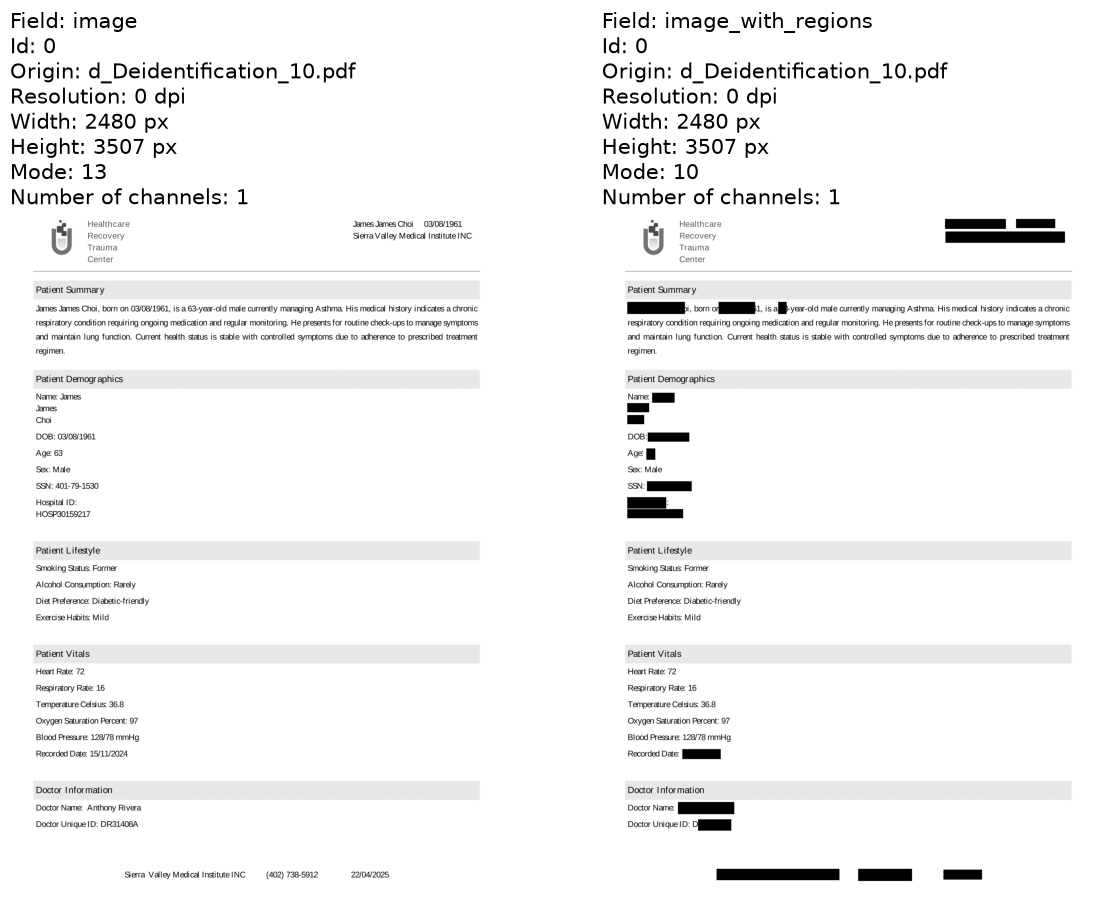

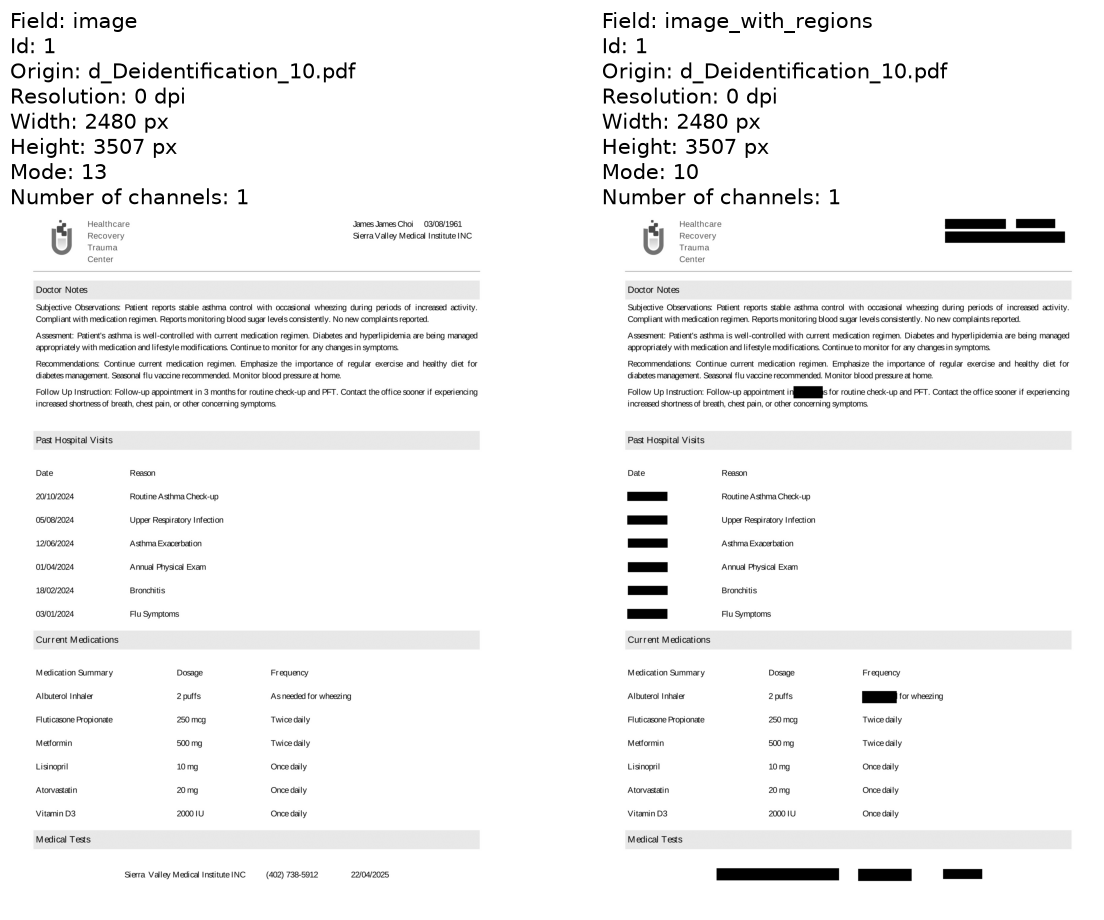

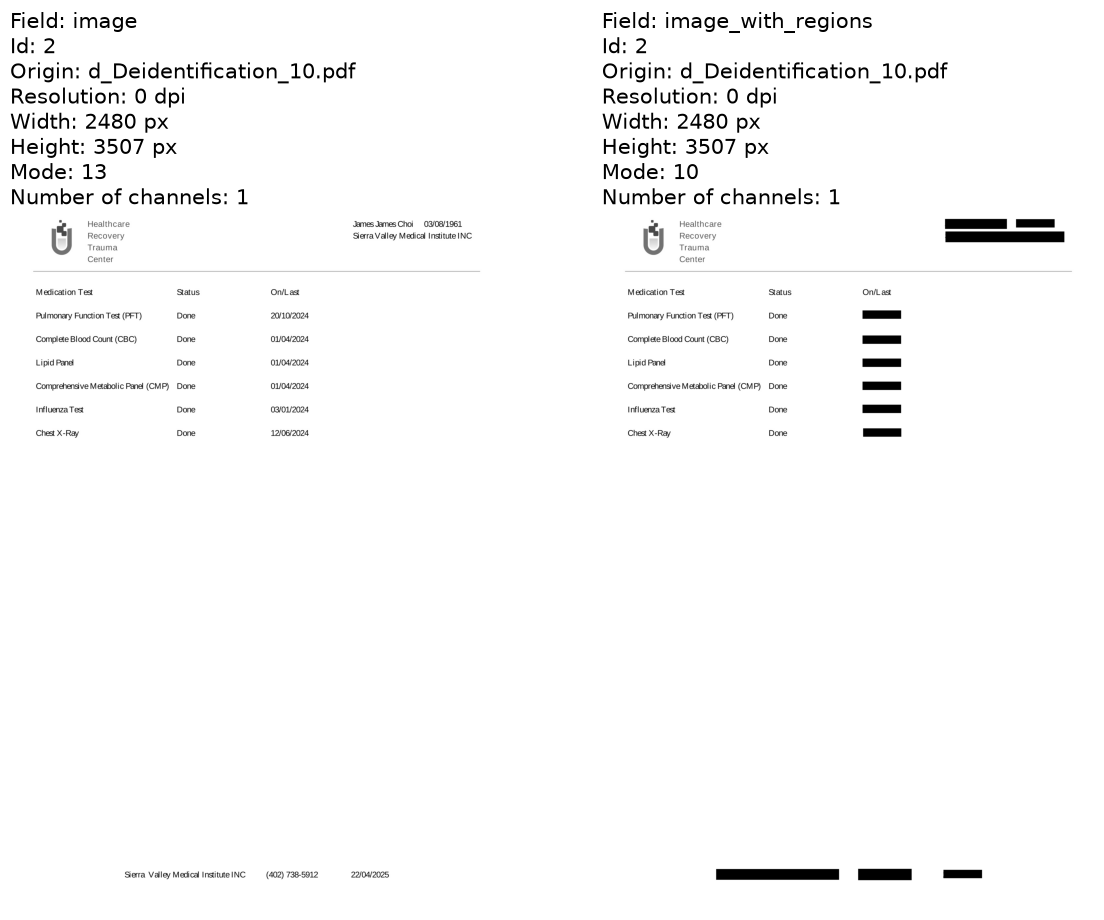

In [27]:
display_images_horizontal(result.orderBy("pagenum"), "image,image_with_regions")